In [1]:
!pip install -q kaggle

!mkdir -p ~/.kaggle && echo "KGAT_eaf1062996e5acbc0728a71a18eb275d" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [9]:
import os
import glob
import pandas as pd
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

csv_path = None
for root, dirs, files in os.walk('ham10000_data'):
    for file in files:
        if 'metadata' in file.lower():
            csv_path = os.path.join(root, file)
            break

if csv_path:
    df = pd.read_csv(csv_path)
    print("Metadata loaded successfully! Total rows:", len(df))
else:
    raise FileNotFoundError("HAM10000_metadata.csv nahi mili!")


image_path_dict = {}
for ext in ['*.jpg', '*.png']:
    for path in glob.glob(os.path.join('ham10000_data', '**', ext), recursive=True):
        name = os.path.splitext(os.path.basename(path))[0]
        image_path_dict[name] = path

df['path'] = df['image_id'].map(image_path_dict)
df = df.dropna(subset=['path']).reset_index(drop=True)
print(f"Total valid images mapped: {len(df)}")

Metadata loaded successfully! Total rows: 10015
Total valid images mapped: 10015


In [10]:
from torch.utils.data import DataLoader
from torchvision import transforms


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])

print(f"Train samples: {len(train_df)}, Validation samples: {len(val_df)}")

Train samples: 8012, Validation samples: 2003


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, balanced_accuracy_score
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model, dataloader):
    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)


    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    macro_f1 = f1
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    prec_per_class, rec_per_class, f1_per_class, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except:
        auc = 0.0

    return {
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Macro-F1': macro_f1,
        'Balanced Accuracy': balanced_acc,
        'AUC': auc
    }

In [15]:
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset


def apply_selected_filter(image_np, filter_type):
    if filter_type == 'Average':
        return cv2.blur(image_np, (5, 5))
    elif filter_type == 'Gaussian':
        return cv2.GaussianBlur(image_np, (5, 5), 0)
    elif filter_type == 'Median':
        return cv2.medianBlur(image_np, 5)
    elif filter_type == 'Sharpening':
        kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
        return cv2.filter2D(image_np, -1, kernel)
    elif filter_type == 'Sobel':
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = cv2.magnitude(sobelx, sobely)
        sobel = np.uint8(np.clip(sobel, 0, 255))
        return cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)
    else:
        return image_np

class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None, filter_type='No Filter'):
        self.df = dataframe
        self.transform = transform
        self.filter_type = filter_type

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label_str = row['dx']
        label = self.class_to_idx[label_str]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))

        filtered_image = apply_selected_filter(image, self.filter_type)

        image_pil = Image.fromarray(filtered_image)
        if self.transform:
            image_tensor = self.transform(image_pil)

        return image_tensor, label


def get_pretrained_model(model_name, num_classes=7):
    if model_name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'EfficientNet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

print("All classes are defined!")

All classes are defined!


In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, balanced_accuracy_score

# 1. Transforms aur Train/Val split setup
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])
print(f"Validation samples for experiments: {len(val_df)}")

# 2. Evaluation function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model, dataloader):
    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except:
        auc = 0.0

    return {
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Macro-F1': f1,
        'Balanced Accuracy': balanced_acc,
        'AUC': auc
    }

# 3. Experiments Loop (Models + Filters)
model_names = ['ResNet50', 'DenseNet121', 'EfficientNet']
filter_types = ['No Filter', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']

results_list = []
num_classes = len(df['dx'].unique())

for m_name in model_names:
    print(f"\n--- Processing Model: {m_name} ---")
    for f_type in filter_types:
        print(f"Running filter: {f_type}")

        val_dataset = SkinLesionDataset(val_df, transform=transform, filter_type=f_type)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

        model = get_pretrained_model(m_name, num_classes=num_classes)
        metrics = evaluate_model(model, val_loader)

        results_list.append({
            'Model': m_name,
            'Filter': f_type,
            'Accuracy': round(metrics['Accuracy'], 4),
            'Precision': round(metrics['Precision'], 4),
            'Recall': round(metrics['Recall'], 4),
            'F1-score': round(metrics['F1-score'], 4),
            'Macro-F1': round(metrics['Macro-F1'], 4),
            'Balanced Accuracy': round(metrics['Balanced Accuracy'], 4),
            'AUC': round(metrics['AUC'], 4)
        })

# 4. Comparison Table print karein
comparison_df = pd.DataFrame(results_list)
print("\n=== Required Comparison Table ===")
display(comparison_df)

Validation samples for experiments: 2003

--- Processing Model: ResNet50 ---
Running filter: No Filter
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Running filter: Average
Running filter: Gaussian
Running filter: Median
Running filter: Sharpening
Running filter: Sobel

--- Processing Model: DenseNet121 ---
Running filter: No Filter
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]


Running filter: Average
Running filter: Gaussian
Running filter: Median
Running filter: Sharpening
Running filter: Sobel

--- Processing Model: EfficientNet ---
Running filter: No Filter
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Running filter: Average
Running filter: Gaussian
Running filter: Median
Running filter: Sharpening
Running filter: Sobel

=== Required Comparison Table ===


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC
0,ResNet50,No Filter,0.0989,0.1500,0.1446,0.0431,0.0431,0.1446,0.5002
1,ResNet50,Average,0.1648,0.1652,0.1620,0.0991,0.0991,0.1620,0.4946
2,ResNet50,Gaussian,0.0689,0.1601,0.1477,0.0339,0.0339,0.1477,0.5118
3,ResNet50,Median,0.1408,0.1096,0.1355,0.0731,0.0731,0.1355,0.4556
4,ResNet50,Sharpening,0.3220,0.1553,0.1557,0.0961,0.0961,0.1557,0.5342
5,ResNet50,Sobel,0.0964,0.0992,0.0968,0.0421,0.0421,0.0968,0.4329
6,DenseNet121,No Filter,0.0529,0.1449,0.1051,0.0516,0.0516,0.1051,0.4963
7,DenseNet121,Average,0.4338,0.1601,0.1323,0.1299,0.1299,0.1323,0.4602
8,DenseNet121,Gaussian,0.3470,0.1273,0.1872,0.0953,0.0953,0.1872,0.5311
9,DenseNet121,Median,0.1088,0.1699,0.1377,0.0423,0.0423,0.1377,0.5272


/tmp/ipykernel_1214/3872193100.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')


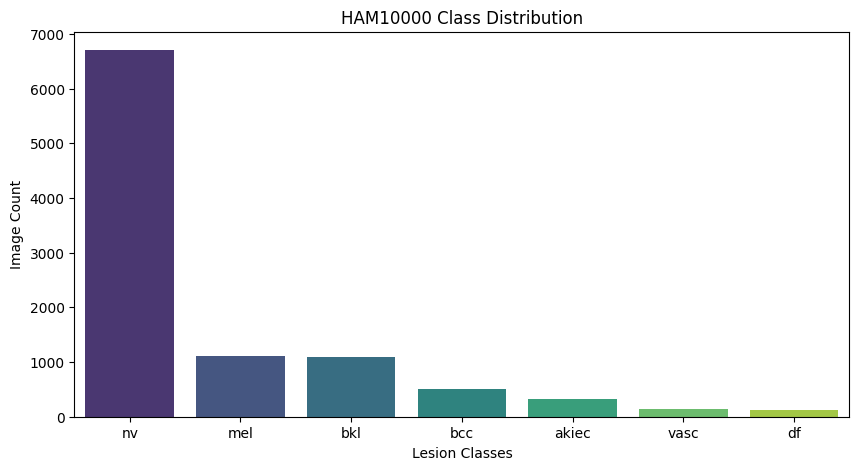

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('HAM10000 Class Distribution')
plt.xlabel('Lesion Classes')
plt.ylabel('Image Count')
plt.show()

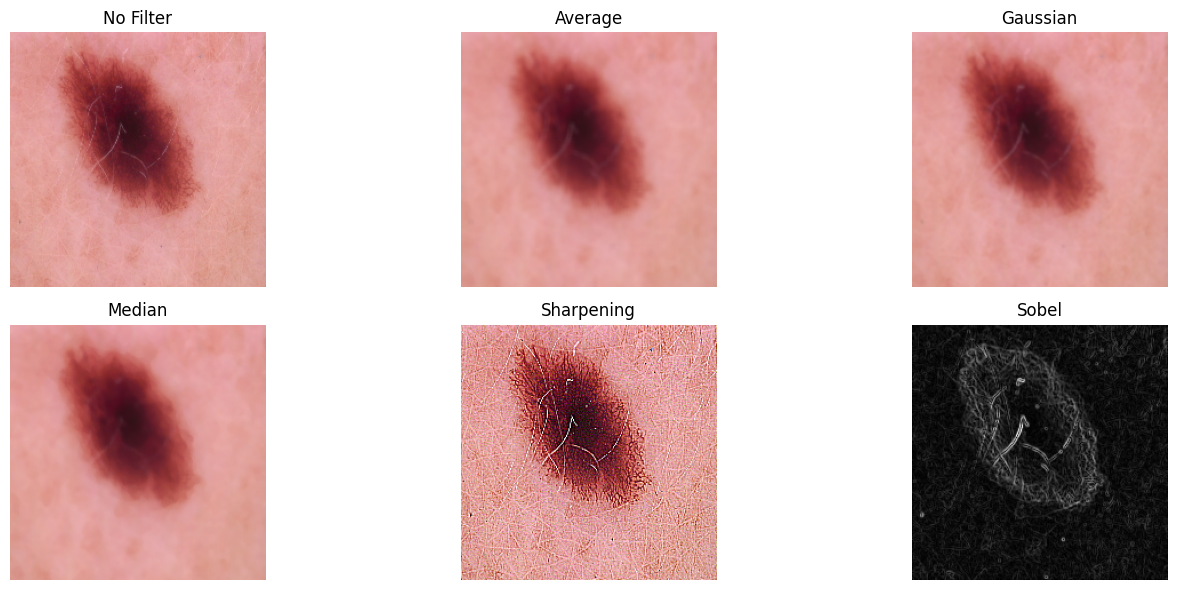

In [18]:
import cv2
import matplotlib.pyplot as plt

# Dataset se aik random sample image uthatay hain
sample_row = df.sample(1).iloc[0]
image = cv2.imread(sample_row['path'])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))

filters = ['No Filter', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']

plt.figure(figsize=(15, 6))
for i, f_type in enumerate(filters):
    filtered_img = apply_selected_filter(image, f_type) # Yeh function humne pehle banaya tha
    plt.subplot(2, 3, i+1)

    if len(filtered_img.shape) == 2 or filtered_img.shape[2] == 1:
        plt.imshow(filtered_img, cmap='gray')
    else:
        plt.imshow(filtered_img)

    plt.title(f_type)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

def generate_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()



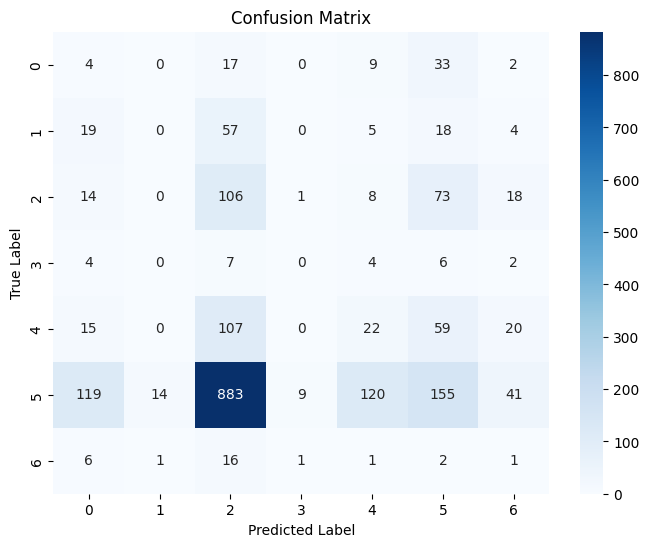

In [21]:
# 1. Pehle function ko define karein (agar pehle nahi kiya)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

def generate_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


generate_confusion_matrix(model, val_loader)